# Data Check
## Data ini hasil dari scraping (web utama -> elektronik category)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
tokopedia_dirty = pd.read_csv('tokopedia.csv')
tokped = tokopedia_dirty.copy()
tokped['harga'] = (
    tokped['harga'].str.replace(r'\D', '', regex=True).astype(int)
)
shopee = pd.read_excel('shopee.xlsx')

# Statistic Descriptive

In [4]:
pd.options.display.float_format = '{:.2f}'.format
tokped.describe()

,harga,rating
count,69.00,69.00
mean,5438820.65,4.95
std,12153057.91,0.07
min,55000.00,4.80
25%,533700.00,4.90
50%,2381000.00,5.00
75%,5519000.00,5.00
max,77999000.00,5.00


In [5]:
shopee.describe() 	

,Harga
count,60.00
mean,7603.45
std,14246.17
min,300.00
25%,1574.75
50%,2500.00
75%,5800.00
max,99000.00


In [6]:
print("Median:", tokped['harga'].median())
print("Skewness:", tokped['harga'].skew())
print("Kurtosis:", tokped['harga'].kurtosis())
print(tokped['harga'].quantile([0.25, 0.5, 0.75]))
iqr = tokped['harga'].quantile(0.75) - tokped['harga'].quantile(0.25)
print("IQR:", iqr)

Median: 2381000.0
Skewness: 4.89064422622286
Kurtosis: 25.51822815379438
0.25    533700.00
0.50   2381000.00
0.75   5519000.00
Name: harga, dtype: float64
IQR: 4985300.0


In [7]:
print("Median:", shopee['Harga'].median())
print("Skewness:", shopee['Harga'].skew())
print("Kurtosis:", shopee['Harga'].kurtosis())
print(shopee['Harga'].quantile([0.25, 0.5, 0.75]))
iqr = shopee['Harga'].quantile(0.75) - shopee['Harga'].quantile(0.25)
print("IQR:", iqr)

Median: 2500.0
Skewness: 4.819076651573049
Kurtosis: 28.970112099341193
0.25   1574.75
0.50   2500.00
0.75   5800.00
Name: Harga, dtype: float64
IQR: 4225.25


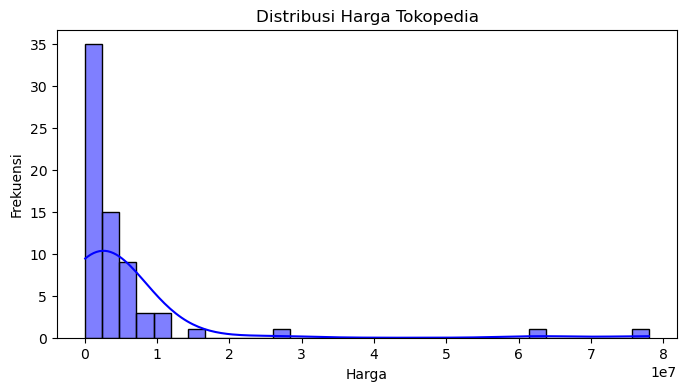

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(tokped['harga'], kde=True, color='blue')
plt.title('Distribusi Harga Tokopedia')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

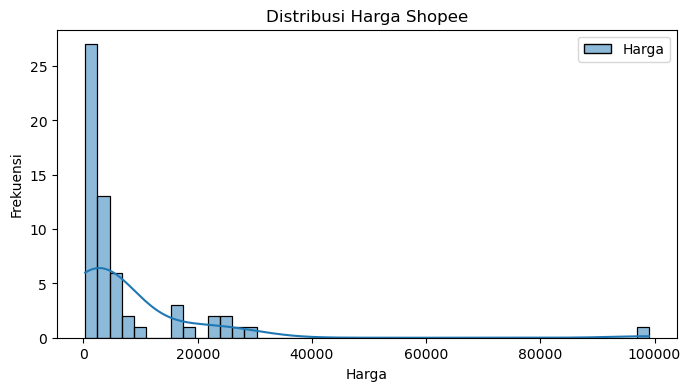

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(shopee, kde=True, color='blue')
plt.title('Distribusi Harga Shopee')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

# Box Plot

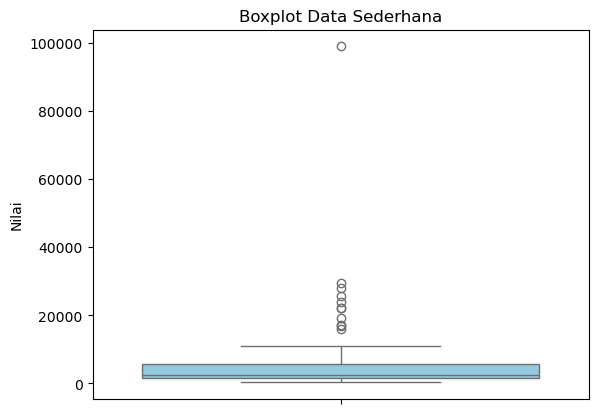

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Membuat Boxplot dengan Seaborn
sns.boxplot(y=shopee['Harga'], color='skyblue')
plt.title("Boxplot Data Sederhana")
plt.ylabel("Nilai")
plt.show()

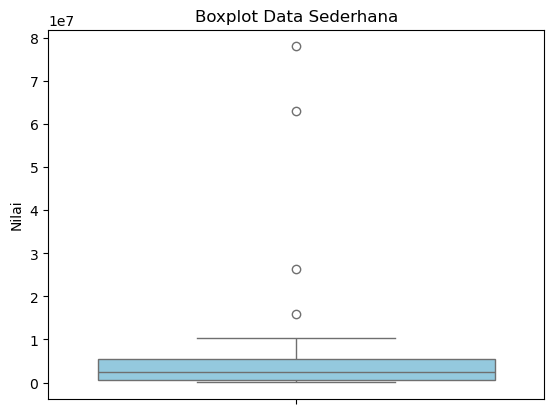

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Membuat Boxplot dengan Seaborn
sns.boxplot(y=tokped['harga'], color='skyblue')
plt.title("Boxplot Data Sederhana")
plt.ylabel("Nilai")
plt.show()

# QQ Plot

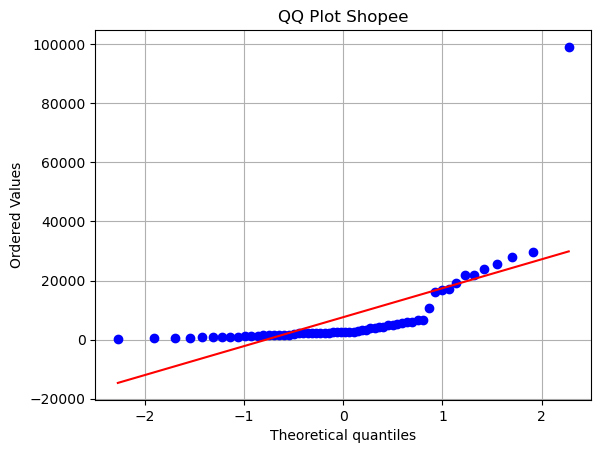

In [14]:
# Membuat QQ Plot
stats.probplot(shopee['Harga'], dist="norm", plot=plt)
plt.title("QQ Plot Shopee")
plt.grid(True)
plt.show()

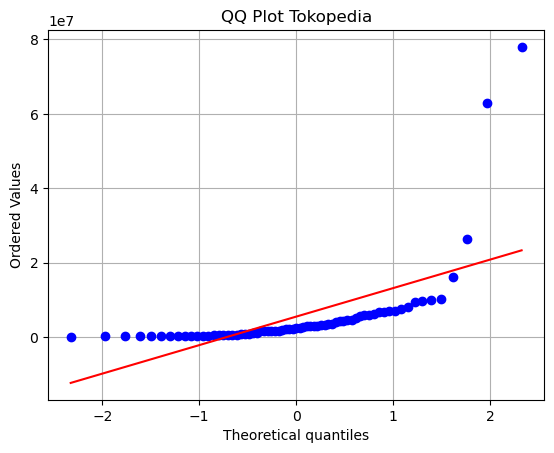

In [15]:
stats.probplot(tokped['harga'], dist="norm", plot=plt)
plt.title("QQ Plot Tokopedia")
plt.grid(True)
plt.show()

# Uji Normalitas 

In [17]:
stat, p_value = stats.shapiro(shopee['Harga'])
print(f"Shapiro-Wilk Stat: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Stat: 0.4716, p-value: 0.0000


In [18]:
stat, p_value = stats.shapiro(tokped['harga'])
print(f"Shapiro-Wilk Stat: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Stat: 0.3994, p-value: 0.0000


# Mann-Whitney U Test

In [48]:
from scipy import stats

stat, p_value = stats.mannwhitneyu(tokped['harga'], shopee['Harga'], alternative='two-sided')

n1 = len(tokped['harga'])
n2 = len(shopee['Harga'])

# Effect Size
rank_biserial = 1 - (2 * stat) / (n1 * n2)
cles = stat / (n1 * n2)

print(f"Nilai U Statistic: {stat}")
print(f"Nilai P-Value    : {p_value:.5f}")
print(f"Rank-Biserial Correlation (r): {rank_biserial:.4f}")
print(f"Common Language Effect Size  : {cles:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Terdapat perbedaan yang signifikan antara kedua kelompok (Tolak H0).")
else:
    print("Kesimpulan: Tidak terdapat perbedaan yang signifikan antara kedua kelompok (Gagal Tolak H0).")

Nilai U Statistic: 4138.0
Nilai P-Value    : 0.00000
Rank-Biserial Correlation (r): -0.9990
Common Language Effect Size  : 0.9995
Kesimpulan: Terdapat perbedaan yang signifikan antara kedua kelompok (Tolak H0).
